In [284]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder



In [285]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [286]:
df.shape

(1338, 7)

In [287]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [288]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [289]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [290]:
df.duplicated().sum()

np.int64(1)

In [291]:
duplicate_mask = df.duplicated(keep=False)
df[duplicate_mask]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [292]:
df = df.drop_duplicates()

In [293]:
y = df['charges']
X = df.drop('charges', axis=1)

In [294]:
X.shape, y.shape

((1337, 6), (1337,))

In [295]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [296]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

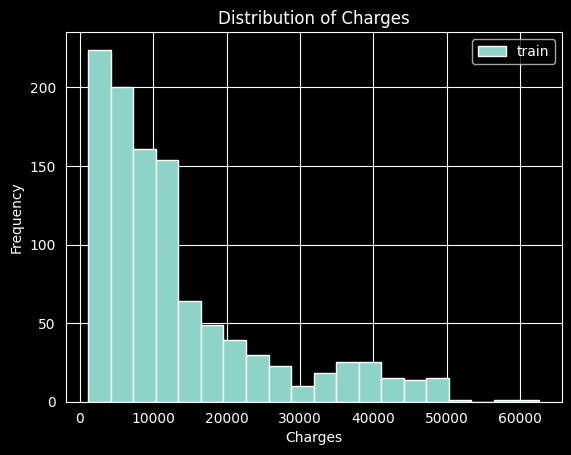

In [297]:
plt.hist(y_train, bins=20, label='train')

plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.title("Distribution of Charges")
plt.legend()
plt.show()


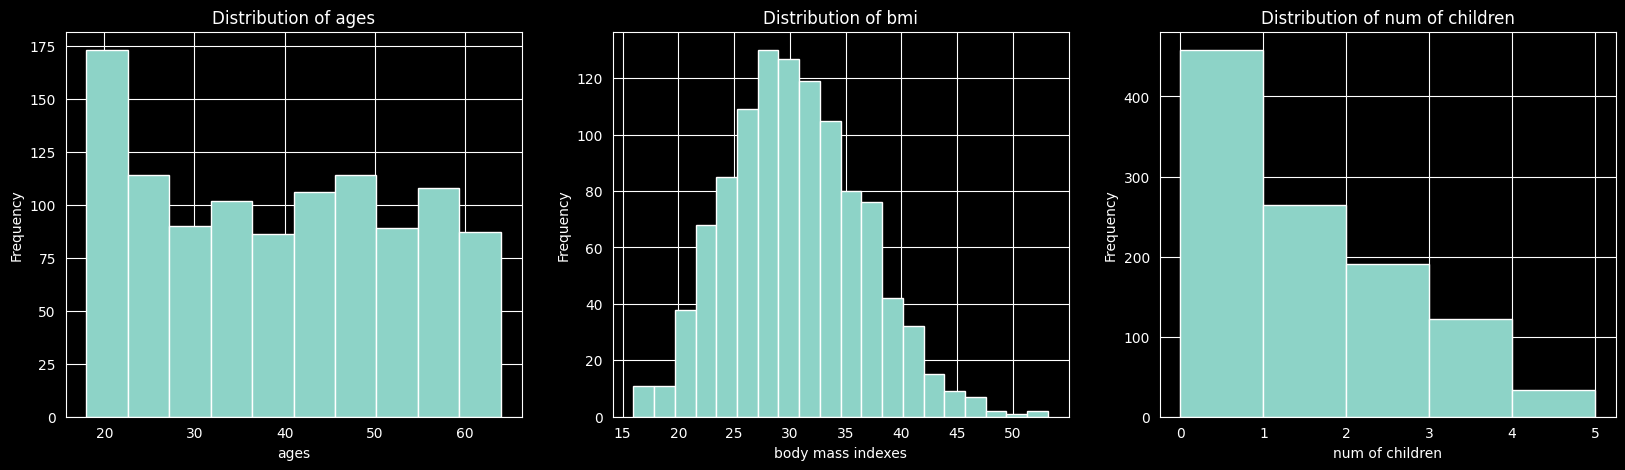

In [298]:
fig, axes = plt.subplots(1,3, figsize=(20,5))


axes[0].hist(X_train['age'], bins=10, label='train')
axes[0].set_xlabel("ages")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of ages")

axes[1].hist(X_train['bmi'], bins=20, label='train')
axes[1].set_xlabel("body mass indexes")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of bmi")

axes[2].hist(X_train['children'], bins=5, label='train')
axes[2].set_xlabel("num of children")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of num of children")



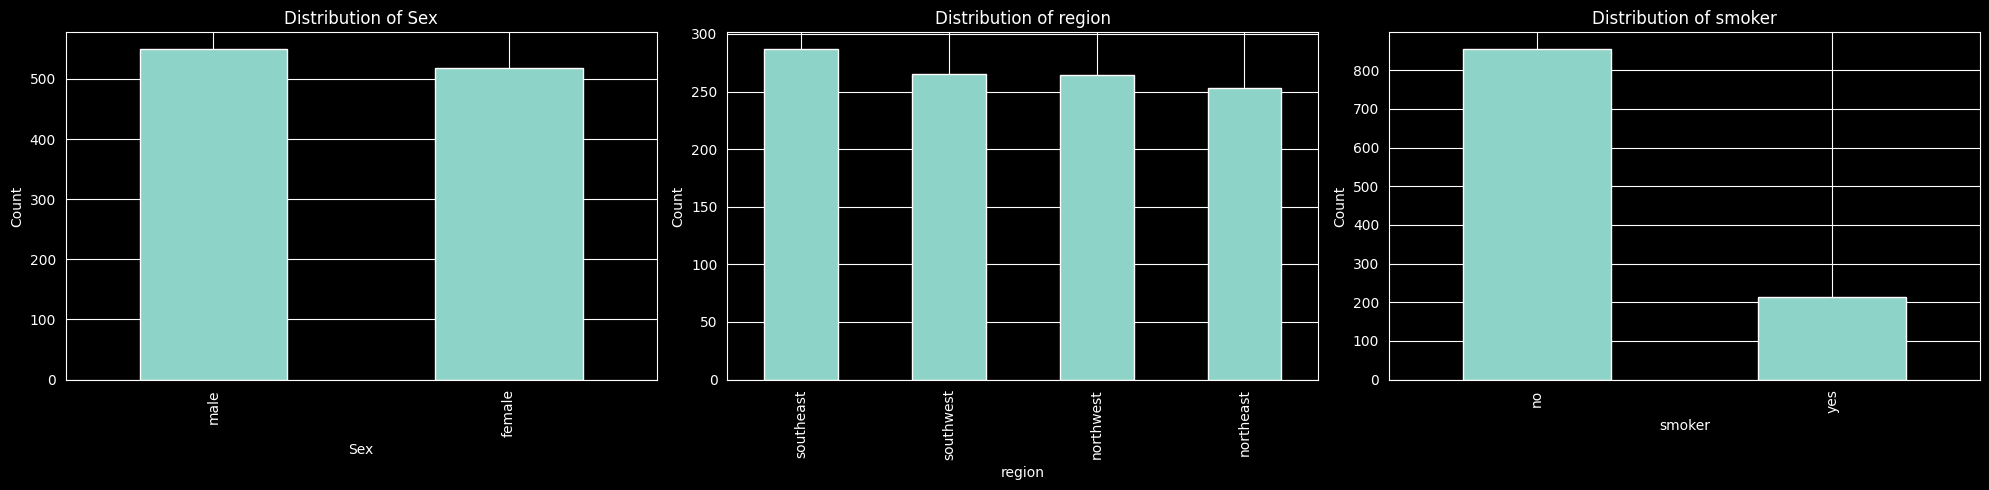

In [299]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

X_train['sex'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Sex")

X_train['region'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel("region")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of region")

X_train['smoker'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_xlabel("smoker")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of smoker")

plt.tight_layout()
plt.show()

In [300]:

enc = OneHotEncoder()

X_train_cat_encoded = enc.fit_transform(X_train[['sex', 'region', 'smoker']])
X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded.toarray(), columns=enc.get_feature_names_out(['sex', 'region', 'smoker']))

In [301]:
X_train_cat_encoded.head()


,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [302]:
enc.feature_name_combiner

'concat'

In [303]:
X_train = pd.concat([X_train, X_train_cat_encoded], axis=1)


In [304]:
X_train.drop(['sex', 'region', 'smoker'], axis=1, inplace=True)
X_train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [305]:
y_train.shape, X_train.shape

((1069,), (1069, 11))

In [306]:
df = pd.concat([X_train, y_train], axis=1)

In [307]:
df.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2396.09590
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3279.86855
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,33471.97189
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13405.39030
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9715.84100


In [308]:
corr_matrix = df.corr()

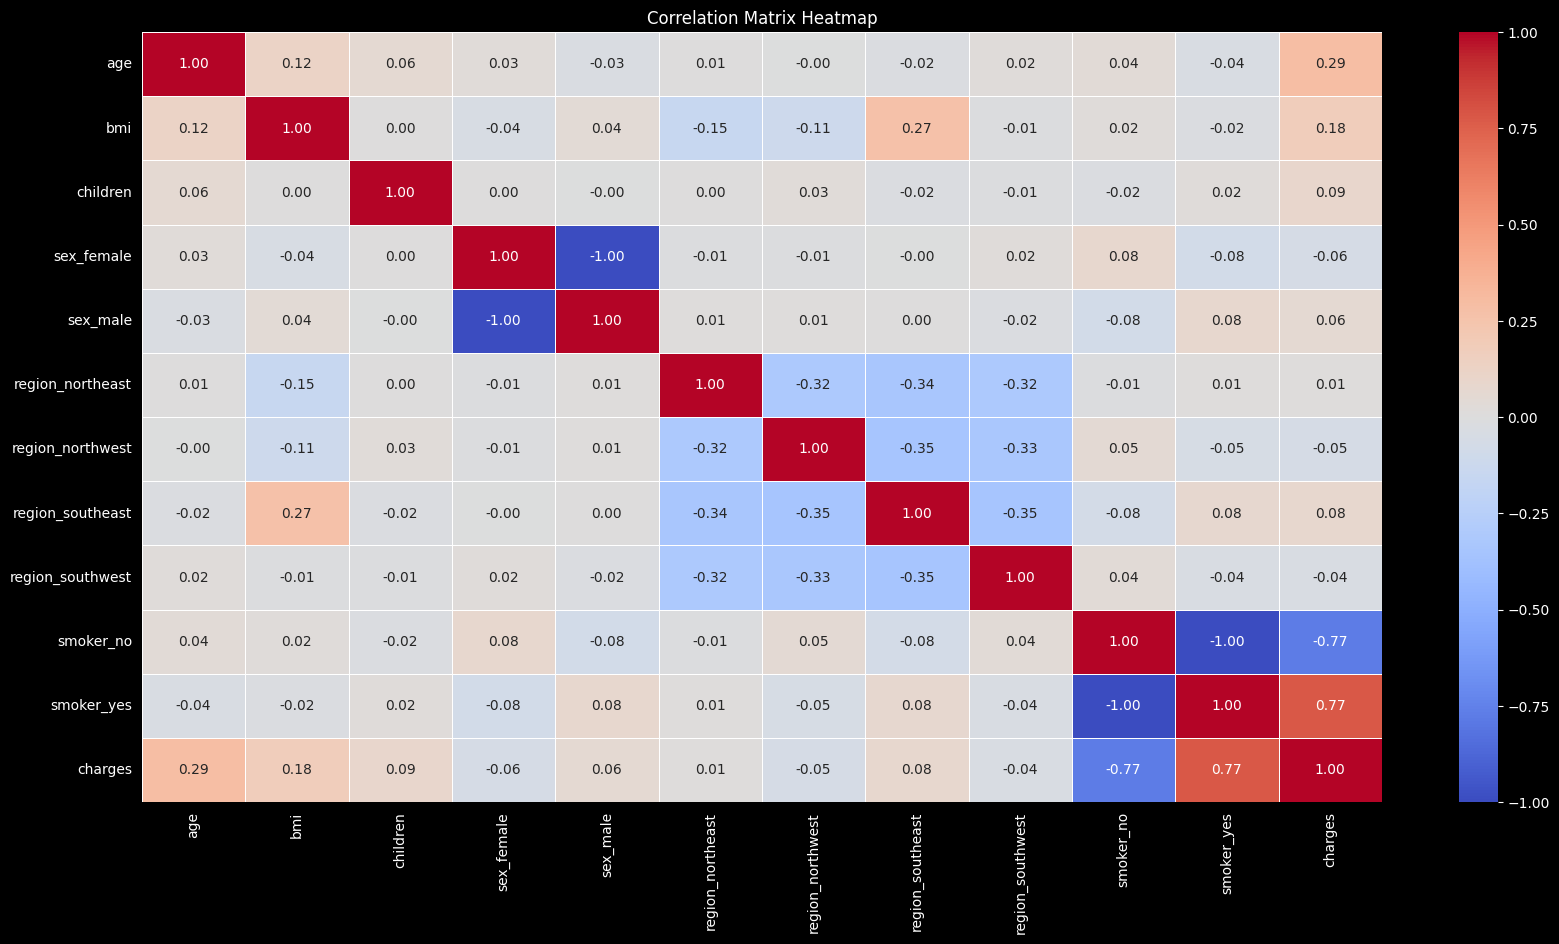

In [309]:
plt.figure(figsize=(20,10))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()